# PoC: Predict log1p(gross) with a tiny Torch MLP
Using the Kaggle Movie Industry dataset. Filters follow EDA decisions: votes≥50k, runtime 30–300, rare categories grouped if freq<5, log1p for skewed numerics and target.

In [43]:
# Comparison configs
CAT_SETS = {
    "CAT_COLS1": ["rating", "genre", "director", "writer", "star", "country", "company"],
    "CAT_COLS2": ["rating", "genre", "country", "company"],
}
MIN_FREQ_OPTIONS = [5, 1]


In [44]:
import os
import math
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Repro
RNG_SEED = 42
np.random.seed(RNG_SEED)
random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

data_path = "../data/raw/movies.csv"
assert os.path.exists(data_path), "Put data/raw/movies.csv in place"

# Filtering thresholds
MIN_VOTES = 50_000
MIN_FREQ = 1
RUNTIME_MIN = 30
RUNTIME_MAX = 300

NUMERIC_COLS = ["budget", "votes", "runtime", "year"]
CAT_COLS1 = ["rating", "genre", "director", "writer", "star", "country", "company"]
CAT_COLS2 = ["rating", "genre", "country", "company"]
TARGET_COL = "gross"  # we predict log1p(gross)


In [45]:
df = pd.read_csv(data_path)
print("Raw shape", df.shape)
print(df.head())


Raw shape (7668, 15)
                                             name rating      genre  year                       released  score      votes  \
0                                     The Shining      R      Drama  1980  June 13, 1980 (United States)    8.4   927000.0   
1                                 The Blue Lagoon      R  Adventure  1980   July 2, 1980 (United States)    5.8    65000.0   
2  Star Wars: Episode V - The Empire Strikes Back     PG     Action  1980  June 20, 1980 (United States)    8.7  1200000.0   
3                                       Airplane!     PG     Comedy  1980   July 2, 1980 (United States)    7.7   221000.0   
4                                      Caddyshack      R     Comedy  1980  July 25, 1980 (United States)    7.3   108000.0   

          director                   writer            star         country      budget        gross             company  runtime  
0  Stanley Kubrick             Stephen King  Jack Nicholson  United Kingdom  19000000.0   

In [46]:
def apply_basic_filters(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    # Drop rows missing target or key fields
    out = out.dropna(subset=[TARGET_COL, "votes", "runtime"])
    # Votes and runtime filters
    out = out[out["votes"] >= MIN_VOTES]
    out = out[(out["runtime"] >= RUNTIME_MIN) & (out["runtime"] <= RUNTIME_MAX)]
    return out


df_filtered = apply_basic_filters(df)
print("After filters", df_filtered.shape)


After filters (3049, 15)


In [47]:
results = []

def run_preprocess_and_train(cat_cols, min_freq):
    # Reuse filtered df, but apply rare grouping with chosen min_freq
    filtered = df_filtered.copy()
    cat_maps = fit_category_maps(filtered, cat_cols, min_freq)
    train_grouped = apply_rare_grouping(train_df, cat_maps)
    val_grouped = apply_rare_grouping(val_df, cat_maps)

    # Frequency encoding on chosen cats
    train_enc, val_enc, _ = frequency_encode(train_grouped, val_grouped, cat_cols)

    # Numeric prep (medians, log1p, scale)
    medians = {c: train_df[c].median() for c in NUMERIC_COLS}
    train_num = train_df.copy()
    val_num = val_df.copy()
    for c in NUMERIC_COLS:
        train_num[c] = train_num[c].fillna(medians[c])
        val_num[c] = val_num[c].fillna(medians[c])
    for c in LOG_COLS:
        train_num[c] = np.log1p(train_num[c].clip(lower=0))
        val_num[c] = np.log1p(val_num[c].clip(lower=0))
    scaler = StandardScaler()
    train_num_scaled = scaler.fit_transform(train_num[NUMERIC_COLS])
    val_num_scaled = scaler.transform(val_num[NUMERIC_COLS])

    X_train = np.hstack([train_num_scaled, train_enc[cat_cols].to_numpy()])
    X_val = np.hstack([val_num_scaled, val_enc[cat_cols].to_numpy()])
    y_train = np.log1p(train_df[TARGET_COL].values).astype(np.float32)
    y_val = np.log1p(val_df[TARGET_COL].values).astype(np.float32)

    input_dim = X_train.shape[1]
    model = MLPRegressor(input_dim)
    train_loader, val_loader = make_loaders(X_train.astype(np.float32), y_train, X_val.astype(np.float32), y_val, batch_size=64)
    history = train_model(model, train_loader, val_loader, epochs=50, lr=1e-3)
    return history, input_dim

for cat_key, cat_cols in CAT_SETS.items():
    for mf in MIN_FREQ_OPTIONS:
        history, input_dim = run_preprocess_and_train(cat_cols, mf)
        results.append({
            "cat_set": cat_key,
            "min_freq": mf,
            "train_mse": history["train_loss"][-1],
            "val_mse": history["val_loss"][-1],
            "train_mae": history["train_mae"][-1],
            "val_mae": history["val_mae"][-1],
        })

results


Epoch 001 | train MSE 261.2758 | val MSE 153.5168 | train MAE 16.0061 | val MAE 12.2301
Epoch 010 | train MSE 3.9889 | val MSE 3.6760 | train MAE 1.5737 | val MAE 1.4281
Epoch 020 | train MSE 2.1915 | val MSE 1.7728 | train MAE 1.1381 | val MAE 0.9672
Epoch 030 | train MSE 1.6736 | val MSE 1.2629 | train MAE 0.9844 | val MAE 0.8004
Epoch 040 | train MSE 1.5132 | val MSE 1.1018 | train MAE 0.9395 | val MAE 0.7671
Epoch 050 | train MSE 1.4595 | val MSE 1.0354 | train MAE 0.9072 | val MAE 0.7227
Epoch 001 | train MSE 277.3043 | val MSE 198.7306 | train MAE 16.5306 | val MAE 13.9663
Epoch 010 | train MSE 4.1802 | val MSE 3.9305 | train MAE 1.5858 | val MAE 1.4515
Epoch 020 | train MSE 2.2020 | val MSE 1.8130 | train MAE 1.1591 | val MAE 0.9830
Epoch 030 | train MSE 1.7162 | val MSE 1.1876 | train MAE 0.9905 | val MAE 0.7985
Epoch 040 | train MSE 1.5249 | val MSE 1.0662 | train MAE 0.9365 | val MAE 0.7585
Epoch 050 | train MSE 1.4844 | val MSE 0.9877 | train MAE 0.9179 | val MAE 0.7154
Epoc

[{'cat_set': 'CAT_COLS1',
  'min_freq': 5,
  'train_mse': np.float64(1.4594919146635594),
  'val_mse': np.float64(1.0353995501995086),
  'train_mae': np.float64(0.907229999701182),
  'val_mae': np.float64(0.72274831533432)},
 {'cat_set': 'CAT_COLS1',
  'min_freq': 1,
  'train_mse': np.float64(1.4844383230576148),
  'val_mse': np.float64(0.9876871764659881),
  'train_mae': np.float64(0.9178604819835761),
  'val_mae': np.float64(0.7154482483863831)},
 {'cat_set': 'CAT_COLS2',
  'min_freq': 5,
  'train_mse': np.float64(1.4904611232953193),
  'val_mse': np.float64(1.0215907335281371),
  'train_mae': np.float64(0.9248751845115271),
  'val_mae': np.float64(0.7243196725845337)},
 {'cat_set': 'CAT_COLS2',
  'min_freq': 1,
  'train_mse': np.float64(1.5123857794663844),
  'val_mse': np.float64(1.0646312534809113),
  'train_mae': np.float64(0.9358569444754185),
  'val_mae': np.float64(0.7589174926280975)}]

In [48]:
train_df, val_df = train_test_split(df_filtered, test_size=0.2, random_state=RNG_SEED)
print("Train", train_df.shape, "Val", val_df.shape)


Train (2439, 15) Val (610, 15)


In [49]:
LOG_COLS = ["budget", "votes"]  # runtime left linear


def fit_category_maps(df: pd.DataFrame, cols, min_freq=MIN_FREQ):
    maps = {}
    for col in cols:
        counts = df[col].fillna("Unknown").value_counts()
        keep = counts[counts >= min_freq].index
        maps[col] = set(keep)
    return maps


def apply_rare_grouping(df: pd.DataFrame, maps):
    out = df.copy()
    for col, keepers in maps.items():
        out[col] = out[col].fillna("Unknown").apply(lambda x: x if x in keepers else "Other")
    return out


def frequency_encode(train_df: pd.DataFrame, val_df: pd.DataFrame, cols):
    train_enc = train_df.copy()
    val_enc = val_df.copy()
    encoders = {}
    for col in cols:
        freq = train_df[col].value_counts(normalize=True)
        encoders[col] = freq
        train_enc[col] = train_df[col].map(freq).fillna(0.0)
        val_enc[col] = val_df[col].map(freq).fillna(0.0)
    return train_enc, val_enc, encoders


def prepare_splits(train_df, val_df):
    # Handle missing numeric with train medians
    medians = {c: train_df[c].median() for c in NUMERIC_COLS}
    train_num = train_df.copy()
    val_num = val_df.copy()
    for c in NUMERIC_COLS:
        train_num[c] = train_num[c].fillna(medians[c])
        val_num[c] = val_num[c].fillna(medians[c])

    # log1p skewed numerics
    for c in LOG_COLS:
        train_num[c] = np.log1p(train_num[c].clip(lower=0))
        val_num[c] = np.log1p(val_num[c].clip(lower=0))

    # Rare grouping then frequency encode
    cat_maps = fit_category_maps(train_df, CAT_COLS, MIN_FREQ)
    train_grouped = apply_rare_grouping(train_df, cat_maps)
    val_grouped = apply_rare_grouping(val_df, cat_maps)
    train_enc, val_enc, _ = frequency_encode(train_grouped, val_grouped, CAT_COLS)

    # Standardize numeric features (after log1p where applicable)
    scaler = StandardScaler()
    train_num_scaled = scaler.fit_transform(train_num[NUMERIC_COLS])
    val_num_scaled = scaler.transform(val_num[NUMERIC_COLS])

    # Assemble feature matrices
    X_train = np.hstack([
        train_num_scaled,
        train_enc[CAT_COLS].to_numpy()
    ])
    X_val = np.hstack([
        val_num_scaled,
        val_enc[CAT_COLS].to_numpy()
    ])

    # Targets
    y_train = np.log1p(train_df[TARGET_COL].values)
    y_val = np.log1p(val_df[TARGET_COL].values)

    return X_train.astype(np.float32), X_val.astype(np.float32), y_train.astype(np.float32), y_val.astype(np.float32), scaler


X_train, X_val, y_train, y_val, scaler = prepare_splits(train_df, val_df)
input_dim = X_train.shape[1]
print("Input dim", input_dim, "Train samples", len(X_train), "Val", len(X_val))


Input dim 8 Train samples 2439 Val 610


### Architecture (specified before training)
Tiny MLP for tabular regression on log1p(gross):
- Input: `input_dim` features (scaled numerics + frequency-encoded categoricals)
- Hidden1: Linear -> 128, ReLU, Dropout(0.1)
- Hidden2: Linear -> 64, ReLU
- Output: Linear -> 1 (predicts log1p(gross))
Loss: MSELoss. Optimizer: Adam (lr=1e-3). Epochs: ~50 with small batch (e.g., 64) to allow overfit. Metrics: MSE/MAE on train/val.


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class MLPRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


def make_loaders(X_train, y_train, X_val, y_val, batch_size=64):
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False),
    )


def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        train_mae = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).unsqueeze(1)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            train_losses.append(loss.item())
            train_mae.append(torch.abs(pred - yb).mean().item())

        model.eval()
        val_losses = []
        val_mae = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device).unsqueeze(1)
                pred = model(xb)
                val_losses.append(loss_fn(pred, yb).item())
                val_mae.append(torch.abs(pred - yb).mean().item())

        history["train_loss"].append(np.mean(train_losses))
        history["val_loss"].append(np.mean(val_losses))
        history["train_mae"].append(np.mean(train_mae))
        history["val_mae"].append(np.mean(val_mae))

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | train MSE {history['train_loss'][-1]:.4f} | val MSE {history['val_loss'][-1]:.4f} | train MAE {history['train_mae'][-1]:.4f} | val MAE {history['val_mae'][-1]:.4f}")

    return history


train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val, batch_size=64)
model = MLPRegressor(input_dim)
history = train_model(model, train_loader, val_loader, epochs=200, lr=1e-3)


Epoch 001 | train MSE 287.1336 | val MSE 213.8573 | train MAE 16.8468 | val MAE 14.5177
Epoch 010 | train MSE 4.7011 | val MSE 4.7408 | train MAE 1.6813 | val MAE 1.6159
Epoch 020 | train MSE 2.5293 | val MSE 2.1829 | train MAE 1.2262 | val MAE 1.0816
Epoch 030 | train MSE 1.8119 | val MSE 1.3458 | train MAE 1.0249 | val MAE 0.8536
Epoch 040 | train MSE 1.5717 | val MSE 1.1090 | train MAE 0.9447 | val MAE 0.7672
Epoch 050 | train MSE 1.4885 | val MSE 1.0513 | train MAE 0.9198 | val MAE 0.7425
Epoch 060 | train MSE 1.4146 | val MSE 1.0194 | train MAE 0.8893 | val MAE 0.7177
Epoch 070 | train MSE 1.4315 | val MSE 1.0063 | train MAE 0.8984 | val MAE 0.7128
Epoch 080 | train MSE 1.4322 | val MSE 1.0131 | train MAE 0.9006 | val MAE 0.7282
Epoch 090 | train MSE 1.3823 | val MSE 1.0187 | train MAE 0.8826 | val MAE 0.6990
Epoch 100 | train MSE 1.3079 | val MSE 0.9727 | train MAE 0.8656 | val MAE 0.7057
Epoch 110 | train MSE 1.3211 | val MSE 0.9970 | train MAE 0.8518 | val MAE 0.7186
Epoch 120 

In [51]:
# Comparison loop (overrides previous results)
results = []
histories = []

def run_preprocess_and_train(cat_cols, min_freq):
    # Rare grouping per min_freq
    cat_maps = fit_category_maps(df_filtered, cat_cols, min_freq)
    train_grouped = apply_rare_grouping(train_df, cat_maps)
    val_grouped = apply_rare_grouping(val_df, cat_maps)

    # Frequency encoding on chosen cats
    train_enc, val_enc, _ = frequency_encode(train_grouped, val_grouped, cat_cols)

    # Numeric prep (medians, log1p, scale)
    medians = {c: train_df[c].median() for c in NUMERIC_COLS}
    train_num = train_df.copy()
    val_num = val_df.copy()
    for c in NUMERIC_COLS:
        train_num[c] = train_num[c].fillna(medians[c])
        val_num[c] = val_num[c].fillna(medians[c])
    for c in LOG_COLS:
        train_num[c] = np.log1p(train_num[c].clip(lower=0))
        val_num[c] = np.log1p(val_num[c].clip(lower=0))
    scaler = StandardScaler()
    train_num_scaled = scaler.fit_transform(train_num[NUMERIC_COLS])
    val_num_scaled = scaler.transform(val_num[NUMERIC_COLS])

    X_train = np.hstack([train_num_scaled, train_enc[cat_cols].to_numpy()])
    X_val = np.hstack([val_num_scaled, val_enc[cat_cols].to_numpy()])
    y_train = np.log1p(train_df[TARGET_COL].values).astype(np.float32)
    y_val = np.log1p(val_df[TARGET_COL].values).astype(np.float32)

    input_dim = X_train.shape[1]
    model = MLPRegressor(input_dim)
    train_loader, val_loader = make_loaders(X_train.astype(np.float32), y_train, X_val.astype(np.float32), y_val, batch_size=64)
    history = train_model(model, train_loader, val_loader, epochs=50, lr=1e-3)
    return history, input_dim

for cat_key, cat_cols in CAT_SETS.items():
    for mf in MIN_FREQ_OPTIONS:
        history, input_dim = run_preprocess_and_train(cat_cols, mf)
        label = f"{cat_key}-min{mf}"
        histories.append({"label": label, "history": history})
        results.append({
            "cat_set": cat_key,
            "min_freq": mf,
            "train_mse": history["train_loss"][-1],
            "val_mse": history["val_loss"][-1],
            "train_mae": history["train_mae"][-1],
            "val_mae": history["val_mae"][-1],
        })

results

Epoch 001 | train MSE 278.2296 | val MSE 186.9483 | train MAE 16.5609 | val MAE 13.5582
Epoch 010 | train MSE 4.3849 | val MSE 4.0455 | train MAE 1.6368 | val MAE 1.5113
Epoch 020 | train MSE 2.2622 | val MSE 1.9082 | train MAE 1.1606 | val MAE 1.0148
Epoch 030 | train MSE 1.6815 | val MSE 1.2964 | train MAE 0.9840 | val MAE 0.8226
Epoch 040 | train MSE 1.4575 | val MSE 1.1383 | train MAE 0.9162 | val MAE 0.7723
Epoch 050 | train MSE 1.4643 | val MSE 1.0682 | train MAE 0.9225 | val MAE 0.7329
Epoch 001 | train MSE 271.2818 | val MSE 175.3759 | train MAE 16.3419 | val MAE 13.1233
Epoch 010 | train MSE 4.1246 | val MSE 3.8741 | train MAE 1.5772 | val MAE 1.4531
Epoch 020 | train MSE 2.0005 | val MSE 1.6068 | train MAE 1.0888 | val MAE 0.9282
Epoch 030 | train MSE 1.5856 | val MSE 1.2010 | train MAE 0.9482 | val MAE 0.8212
Epoch 040 | train MSE 1.5106 | val MSE 1.0363 | train MAE 0.9373 | val MAE 0.7193
Epoch 050 | train MSE 1.5119 | val MSE 1.0309 | train MAE 0.9130 | val MAE 0.7324
Epoc

[{'cat_set': 'CAT_COLS1',
  'min_freq': 5,
  'train_mse': np.float64(1.4642916077222579),
  'val_mse': np.float64(1.0682098150253296),
  'train_mae': np.float64(0.9225162420517359),
  'val_mae': np.float64(0.7328990995883942)},
 {'cat_set': 'CAT_COLS1',
  'min_freq': 1,
  'train_mse': np.float64(1.5119206202335846),
  'val_mse': np.float64(1.0309030652046203),
  'train_mae': np.float64(0.9130358604284433),
  'val_mae': np.float64(0.7323960959911346)},
 {'cat_set': 'CAT_COLS2',
  'min_freq': 5,
  'train_mse': np.float64(1.469375559916863),
  'val_mse': np.float64(1.0487393677234649),
  'train_mae': np.float64(0.9144884118667016),
  'val_mae': np.float64(0.7471305549144744)},
 {'cat_set': 'CAT_COLS2',
  'min_freq': 1,
  'train_mse': np.float64(1.6284491083560846),
  'val_mse': np.float64(1.0361114323139191),
  'train_mae': np.float64(0.9561447440049587),
  'val_mae': np.float64(0.7258383572101593)}]

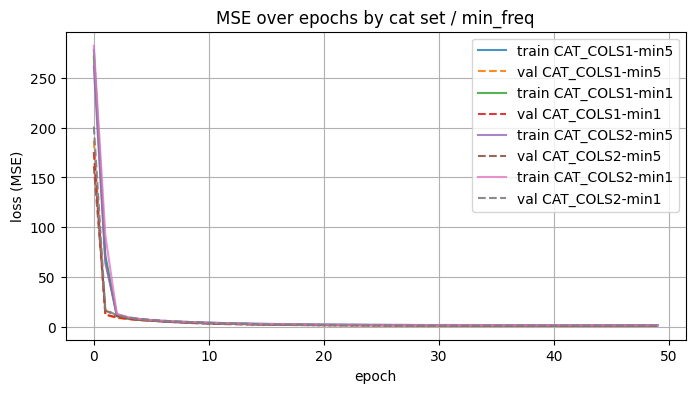

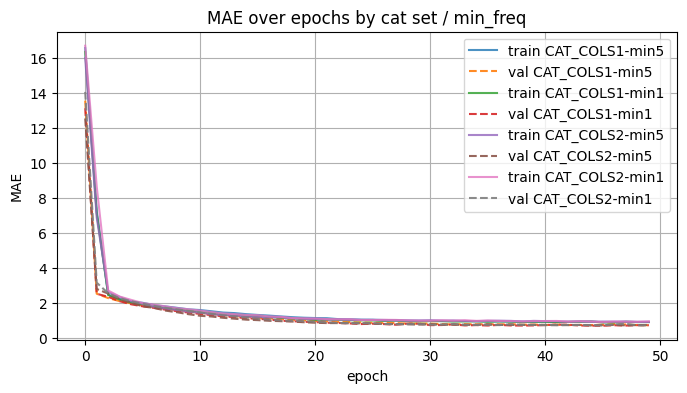

,cat_set,min_freq,train_mse,val_mse,train_mae,val_mae
0,CAT_COLS1,5,1.464292,1.068210,0.922516,0.732899
1,CAT_COLS1,1,1.511921,1.030903,0.913036,0.732396
2,CAT_COLS2,5,1.469376,1.048739,0.914488,0.747131
3,CAT_COLS2,1,1.628449,1.036111,0.956145,0.725838


In [52]:
# Plots comparing combinations
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
for item in histories:
    h = item["history"]
    plt.plot(h["train_loss"], linestyle="-", alpha=0.8, label=f"train {item['label']}")
    plt.plot(h["val_loss"], linestyle="--", alpha=0.9, label=f"val {item['label']}")
plt.title("MSE over epochs by cat set / min_freq")
plt.xlabel("epoch")
plt.ylabel("loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
for item in histories:
    h = item["history"]
    plt.plot(h["train_mae"], linestyle="-", alpha=0.8, label=f"train {item['label']}")
    plt.plot(h["val_mae"], linestyle="--", alpha=0.9, label=f"val {item['label']}")
plt.title("MAE over epochs by cat set / min_freq")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

results_df = pd.DataFrame(results)
results_df

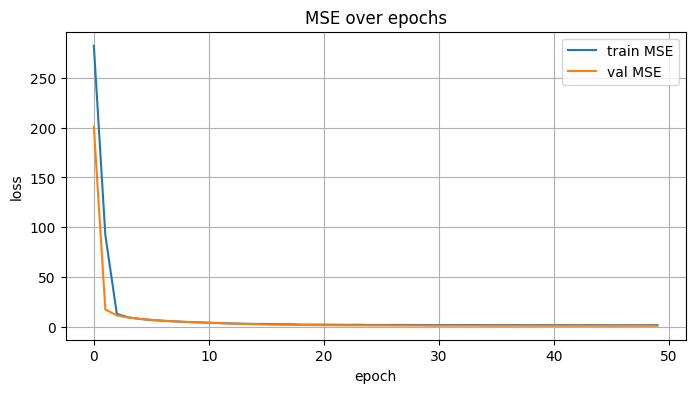

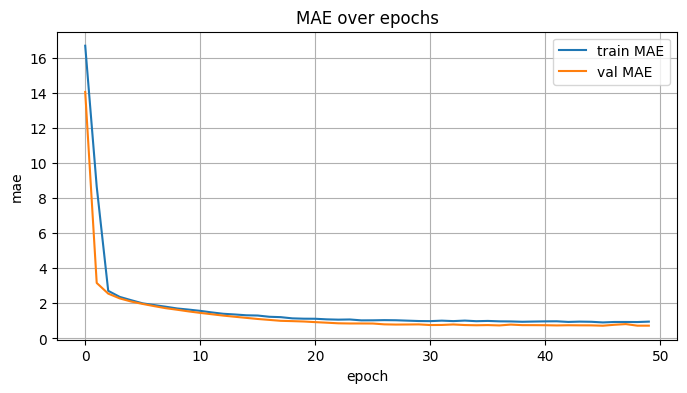

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="train MSE")
plt.plot(history["val_loss"], label="val MSE")
plt.title("MSE over epochs")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history["train_mae"], label="train MAE")
plt.plot(history["val_mae"], label="val MAE")
plt.title("MAE over epochs")
plt.xlabel("epoch")
plt.ylabel("mae")
plt.legend()
plt.grid(True)
plt.show()


In [54]:
# Evaluate on val with MAE in original dollars (approx)
model.eval()
with torch.no_grad():
    val_preds = []
    val_targets = []
    for xb, yb in val_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy().squeeze()
        val_preds.append(preds)
        val_targets.append(yb.numpy())
    val_preds = np.concatenate(val_preds)
    val_targets = np.concatenate(val_targets)

val_mae_log = np.mean(np.abs(val_preds - val_targets))
val_mae_dollars = np.mean(np.abs(np.expm1(val_preds) - np.expm1(val_targets)))
print(f"Val MAE (log space): {val_mae_log:.4f}")
print(f"Val MAE (dollars, approx): {val_mae_dollars:,.0f}")

# Show a few predictions
for i in range(5):
    pred = val_preds[i]
    target = val_targets[i]
    print(f"Example {i}: pred gross ${np.expm1(pred):,.0f} vs target ${np.expm1(target):,.0f}")


Val MAE (log space): 0.6948
Val MAE (dollars, approx): 74,131,896
Example 0: pred gross $67,851,184 vs target $159,814,528
Example 1: pred gross $54,463,832 vs target $76,586,296
Example 2: pred gross $26,682,276 vs target $44,723,204
Example 3: pred gross $98,371,400 vs target $90,753,880
Example 4: pred gross $557,690,496 vs target $343,471,744


Notes:
- This PoC intentionally tries to overfit; expect val metrics to be worse than train.
- Frequency encoding is leak-safe (fit on train, applied to val). For stronger models, swap to target-mean with CV or embeddings.
- To rerun quickly on CPU/GPU: just execute cells top-to-bottom after ensuring `requirements.txt` is installed.